In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNetCV, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

In [2]:
df = pd.read_excel('data/healthcare_rest.xlsx')
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610


In [3]:
# add artificial genetical_risk column to be consistent with young model
df['Genetical_Risk'] = 0

In [4]:
df.shape

(29904, 14)

In [5]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount', 'Genetical_Risk'],
      dtype='object')

In [6]:
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.head(1)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0


<h2 align="center">🧹 Data Cleaning</h2>

### Handle Missing Values

In [7]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           9
employment_status        1
income_level             9
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [8]:
df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

### Handle Duplicates

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29886.000000,29886.000000,29886.000000,29886.000000,29886.0
mean,43.396105,2.379910,23.364184,20892.303821,0.0
std,13.412657,1.431201,24.740339,6936.813440,0.0
min,26.000000,-3.000000,1.000000,3625.000000,0.0
25%,34.000000,1.000000,7.000000,15697.250000,0.0
50%,42.000000,3.000000,17.000000,20489.000000,0.0
75%,52.000000,3.000000,32.000000,26360.000000,0.0
max,356.000000,5.000000,930.000000,43471.000000,0.0


#### Data Cleaning: Handle number_of_dependants

In [12]:
df['number_of_dependants'].value_counts().unique

<bound method Series.unique of number_of_dependants
 3    9492
 2    6187
 4    4723
 0    4572
 1    3209
 5    1653
-1      30
-3      20
Name: count, dtype: int64>

In [13]:
df[df.number_of_dependants < 0 ]['number_of_dependants'].unique()

array([-1, -3])

In [14]:
df['number_of_dependants'] = df['number_of_dependants'].abs()

df['number_of_dependants'].describe()

count    29886.000000
mean         2.385933
std          1.421137
min          0.000000
25%          1.000000
50%          3.000000
75%          3.000000
max          5.000000
Name: number_of_dependants, dtype: float64

In [15]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29886.000000,29886.000000,29886.000000,29886.000000,29886.0
mean,43.396105,2.385933,23.364184,20892.303821,0.0
std,13.412657,1.421137,24.740339,6936.813440,0.0
min,26.000000,0.000000,1.000000,3625.000000,0.0
25%,34.000000,1.000000,7.000000,15697.250000,0.0
50%,42.000000,3.000000,17.000000,20489.000000,0.0
75%,52.000000,3.000000,32.000000,26360.000000,0.0
max,356.000000,5.000000,930.000000,43471.000000,0.0


### Handle Numeric Columns

In [16]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount',
       'genetical_risk'],
      dtype='object')

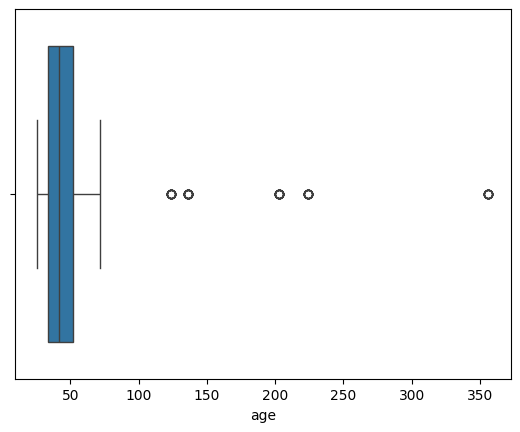

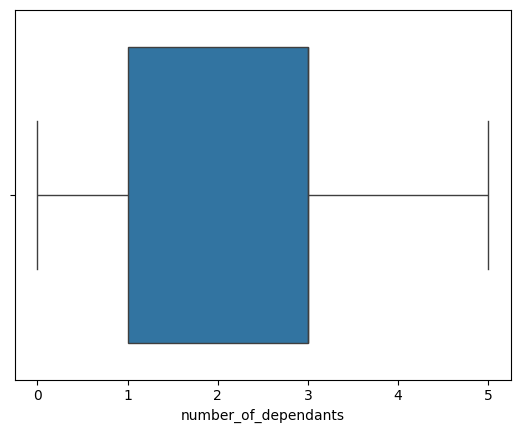

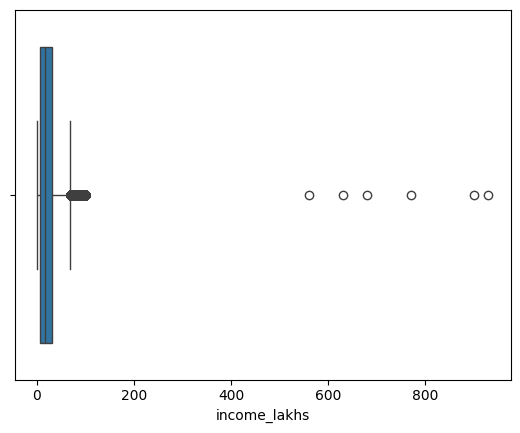

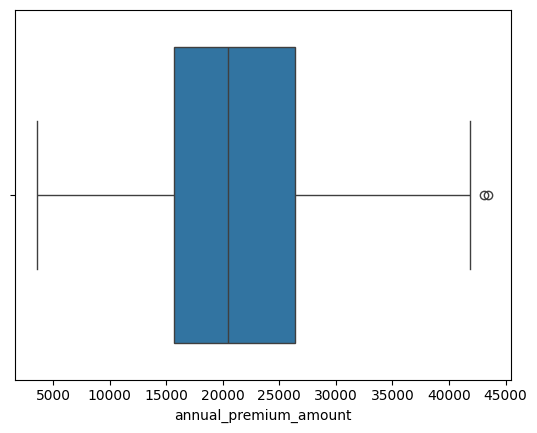

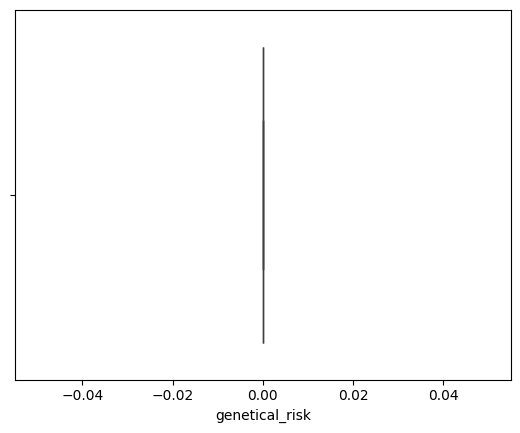

In [17]:
for col in numeric_columns:
    sns.boxplot(x=df[col])
    plt.show()

### Hanlde Outlier: Age Column

In [18]:
df[df['age'] > 100]['age'].value_counts()

age
136    15
203    13
124    11
224    10
356     9
Name: count, dtype: int64

In [19]:
df[df['age'] > 100]['age'].unique()

array([224, 124, 136, 203, 356])

In [20]:
df[df['age'] > 100]['age'].value_counts().unique()

array([15, 13, 11, 10,  9])

In [21]:
df[df['age'] > 100]['age'].value_counts()

age
136    15
203    13
124    11
224    10
356     9
Name: count, dtype: int64

In [22]:
df[df['age'] >= 100].shape[0]

58

In [23]:
df1 = df[df['age'] < 100]
df1.age.describe()

count    29828.000000
mean        43.095380
std         11.041991
min         26.000000
25%         34.000000
50%         42.000000
75%         52.000000
max         72.000000
Name: age, dtype: float64

### Handle Outlier: Income Column

<Axes: xlabel='income_lakhs', ylabel='Count'>

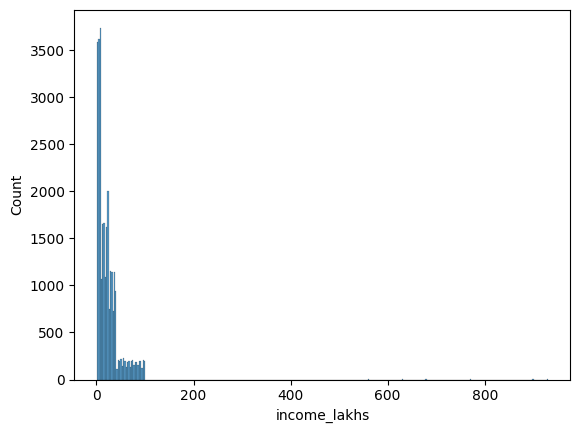

In [25]:
sns.histplot(df.income_lakhs)

In [26]:
df.income_lakhs.quantile([0.25, 0.75])

0.25     7.0
0.75    32.0
Name: income_lakhs, dtype: float64

In [27]:
def get_iqr_bounds(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3-Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

lower, upper = get_iqr_bounds(df1['income_lakhs'])
lower, upper



(-30.5, 69.5)

In [28]:
df1[df1.income_lakhs>upper].shape

(2090, 14)

#### Upper bound value 67 is not too much high, we can be decided correct upper bound after dicussion with manager 


In [29]:
quantile_thresold = df1.income_lakhs.quantile(0.999)
quantile_thresold

np.float64(100.0)

In [30]:
df1[df1.income_lakhs > quantile_thresold].shape

(6, 14)

In [31]:
df2 = df1[df1.income_lakhs<=quantile_thresold].copy()
df2.shape

(29822, 14)

In [32]:
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29822.000000,29822.000000,29822.000000,29822.000000,29822.0
mean,43.094896,2.387734,23.226343,20900.689223,0.0
std,11.042430,1.420644,22.455408,6928.192115,0.0
min,26.000000,0.000000,1.000000,6538.000000,0.0
25%,34.000000,1.000000,7.000000,15705.250000,0.0
50%,42.000000,3.000000,17.000000,20495.500000,0.0
75%,52.000000,3.000000,32.000000,26360.000000,0.0
max,72.000000,5.000000,100.000000,43471.000000,0.0


<Axes: xlabel='income_lakhs', ylabel='Count'>

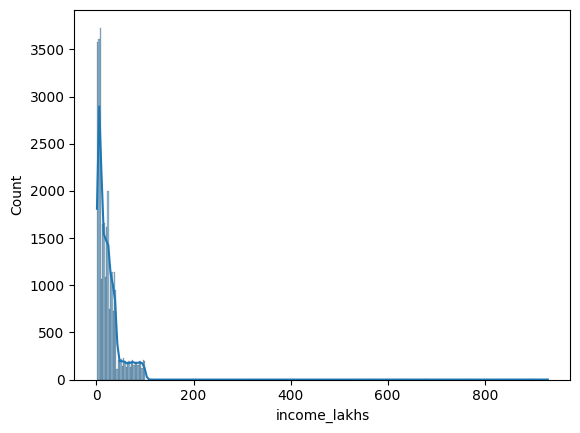

In [33]:
sns.histplot(df1['income_lakhs'], kde=True)

<Axes: xlabel='income_lakhs', ylabel='Count'>

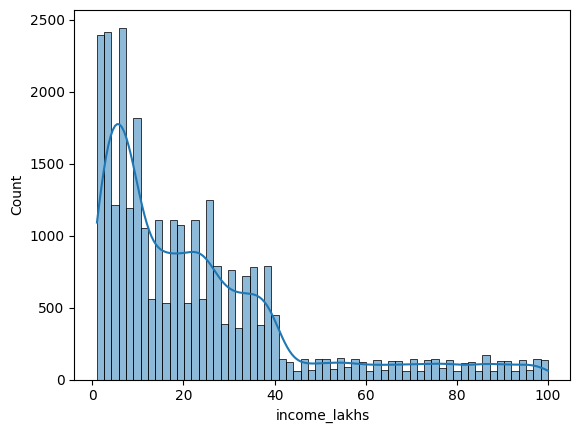

In [34]:
sns.histplot(df2['income_lakhs'], kde=True)

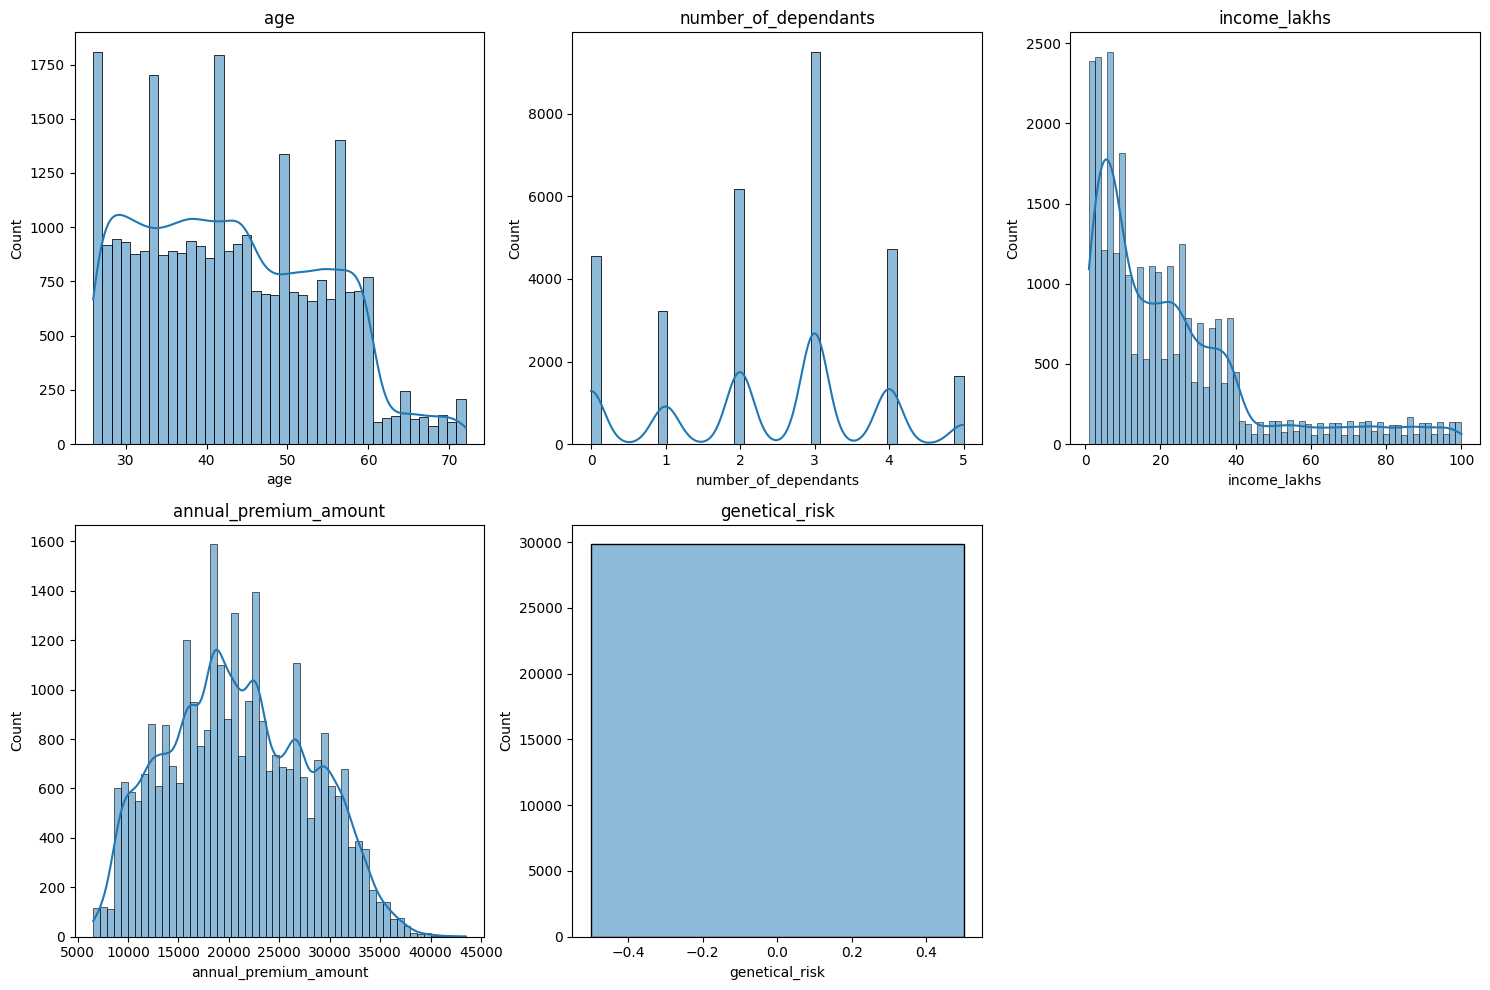

In [35]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))  # Adjust the size to ensure plots are not squeezed

for i, column in enumerate(numeric_columns):
    # Locating the correct subplot using integer division and modulus
    ax = axs[i // 3, i % 3]  # Row index is i//3, column index is i%3
    sns.histplot(df2[column], kde=True, ax=ax)
    ax.set_title(column)

# If the last subplot axis is unused, you can turn it off
if len(numeric_columns) % 3 != 0:
    for j in range(len(numeric_columns), 6):  # This will disable any unused subplots
        axs.flat[j].set_visible(False)

plt.tight_layout()
plt.show()

### Bivariate Analysis: Numeric Columns

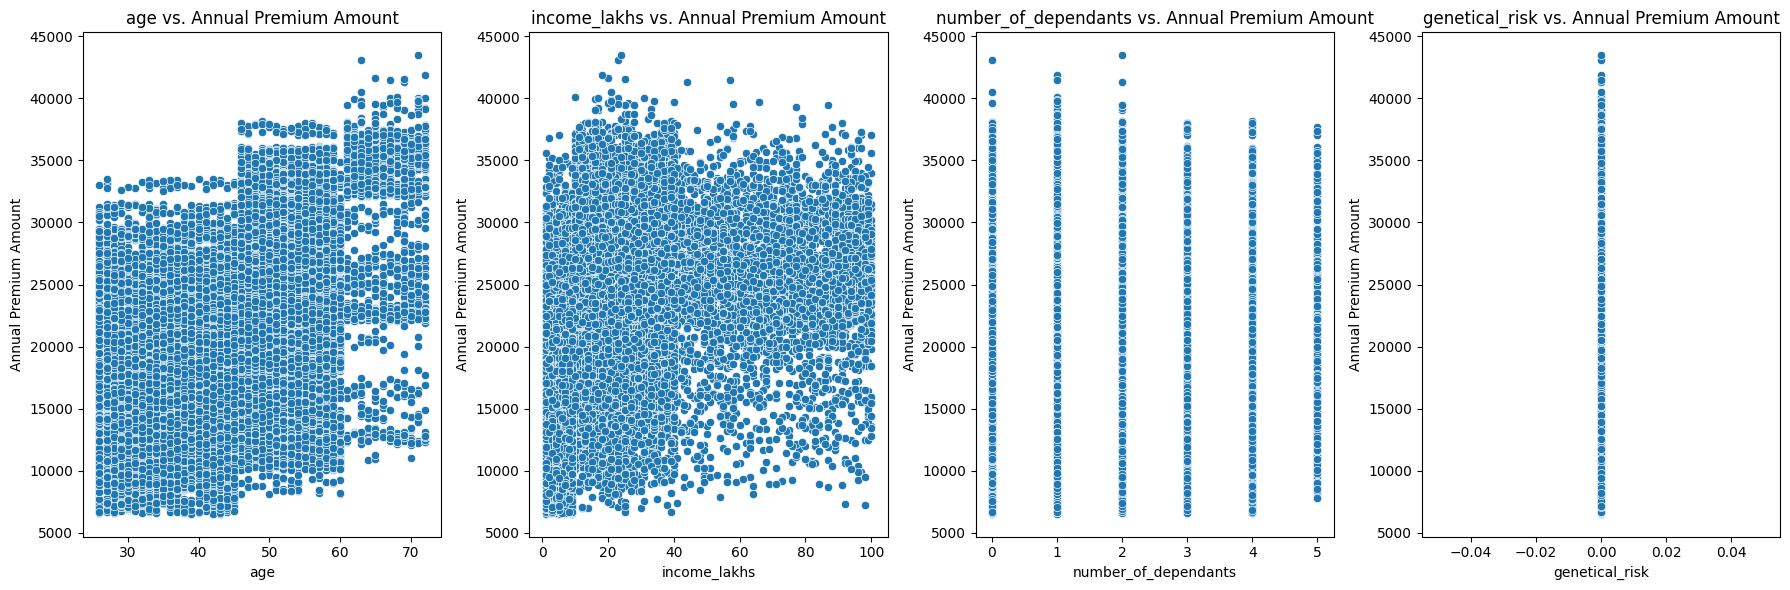

In [36]:
numeric_features = ['age', 'income_lakhs', 'number_of_dependants', 'genetical_risk']

fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 6))  # Adjust figure size as necessary

for ax, column in zip(axes, numeric_features):
    sns.scatterplot(x=df2[column], y=df2['annual_premium_amount'], ax=ax)
    ax.set_title(f'{column} vs. Annual Premium Amount')
    ax.set_xlabel(column)
    ax.set_ylabel('Annual Premium Amount')

plt.tight_layout()  # Adjust layout
plt.show()

### EDA on Categorical Columns

In [37]:
categorical_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'medical_history', 'insurance_plan']
for col in categorical_cols:
    print(col, ":", df2[col].unique())

gender : ['Male' 'Female']
region : ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status : ['No Smoking' 'Regular' 'Occasional' 'Does Not Smoke' 'Not Smoking'
 'Smoking=0']
employment_status : ['Salaried' 'Self-Employed' 'Freelancer']
income_level : ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history : ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan : ['Bronze' 'Silver' 'Gold']


In [38]:
df2['smoking_status'] = df2['smoking_status'].replace({
    'Not Smoking': 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Smoking=0': 'No Smoking'
})

df2['smoking_status'].unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

### Univariate Analysis

In [39]:
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0


In [40]:
pct_count = df2['gender'].value_counts(normalize=True)*100
pct_count

gender
Male      54.912481
Female    45.087519
Name: proportion, dtype: float64

<Axes: xlabel='gender'>

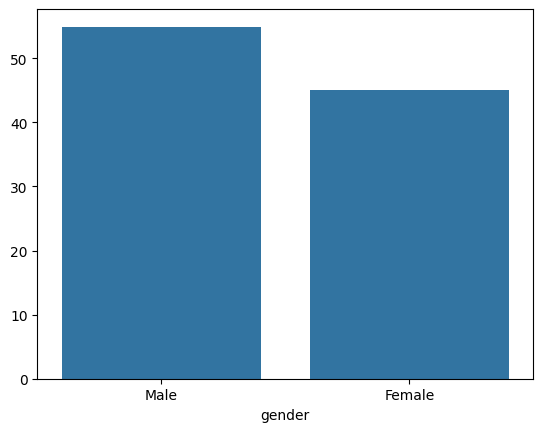

In [41]:
sns.barplot(x=pct_count.index, y=pct_count.values)

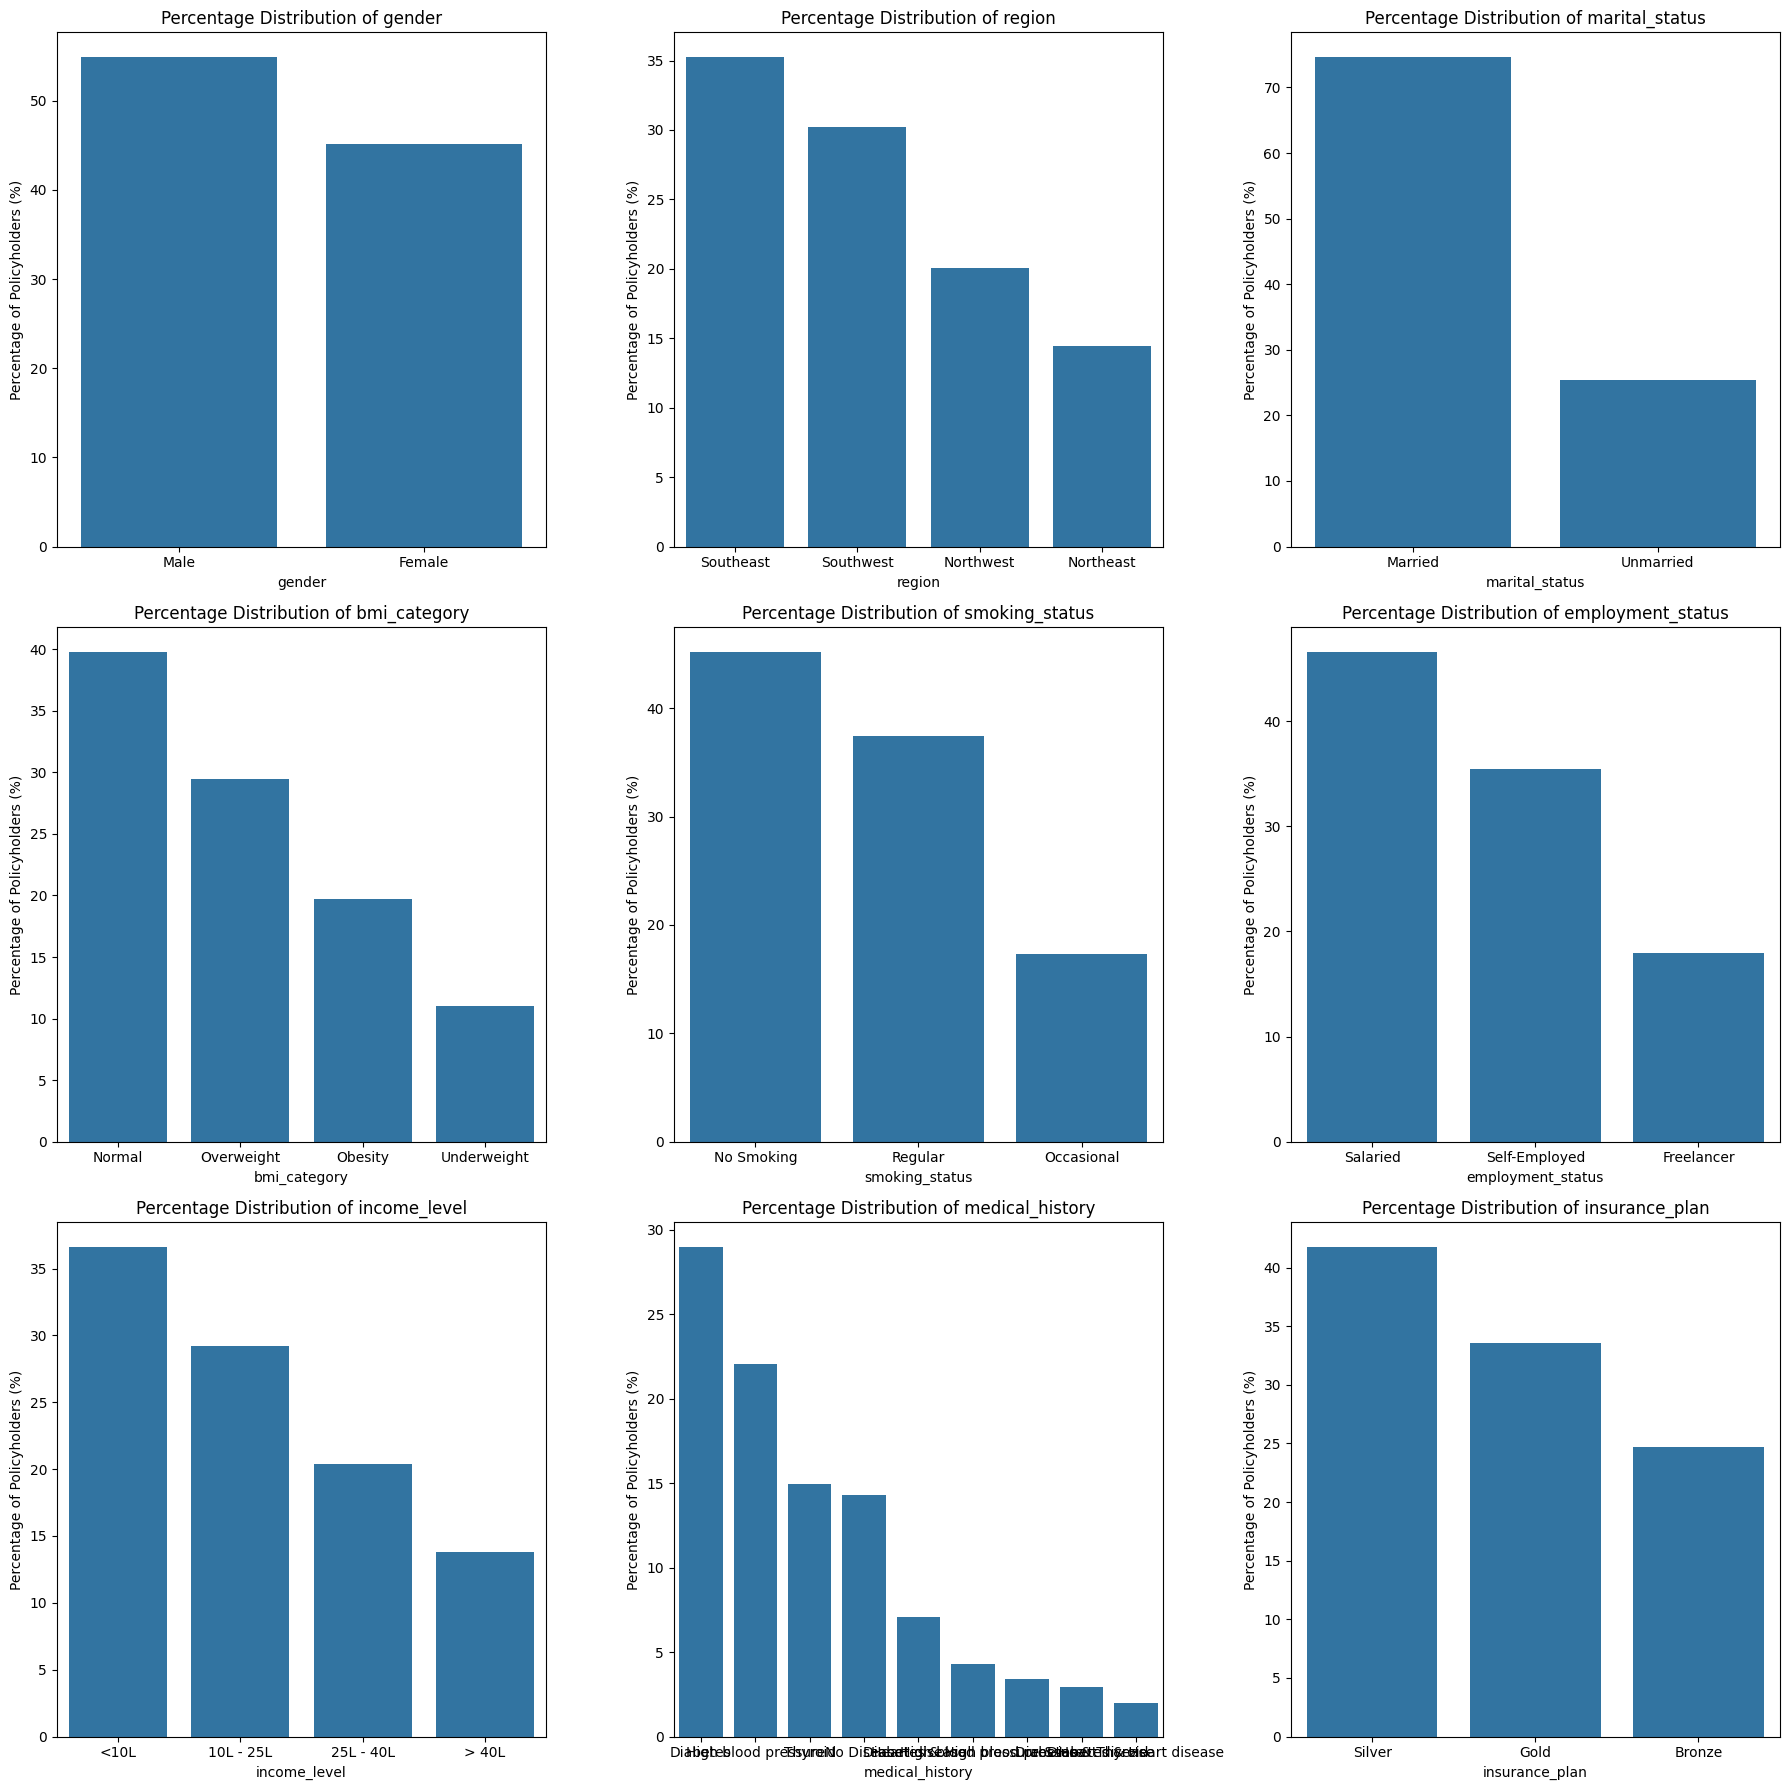

In [42]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))  # Adjust figure size as necessary
axes = axes.flatten()  # Flatten the 2D array of axes into 1D for easier iteration

for ax, column in zip(axes, categorical_cols):
    # Calculate the percentage distribution of each category
    category_counts = df2[column].value_counts(normalize=True) * 100  # normalize=True gives the relative frequencies
    
    # Plotting the distribution using barplot
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    ax.set_title(f'Percentage Distribution of {column}')
    ax.set_ylabel('Percentage of Policyholders (%)')
    ax.set_xlabel(column)  # Set xlabel to the column name for clarity

plt.tight_layout()  # Adjusts plot parameters for better fit in the figure window
plt.show()

### Bivariate Analysis

insurance_plan  Bronze  Gold  Silver
income_level                        
10L - 25L          799  3554    4354
25L - 40L          301  2631    3142
<10L              6054   527    4341
> 40L              214  3287     618


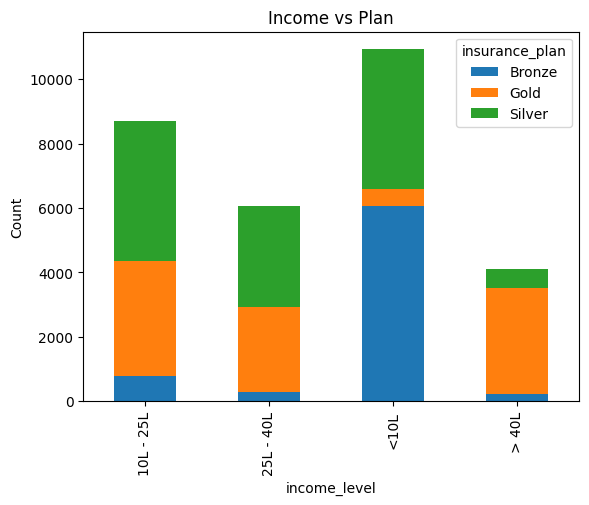

In [43]:
# Cross-tabulation of gender and smoking status
crosstab = pd.crosstab(df2['income_level'], df2['insurance_plan'])
print(crosstab)

# Plotting the crosstab
crosstab.plot(kind='bar', stacked=True)
plt.title('Income vs Plan')
plt.ylabel('Count')
plt.show()

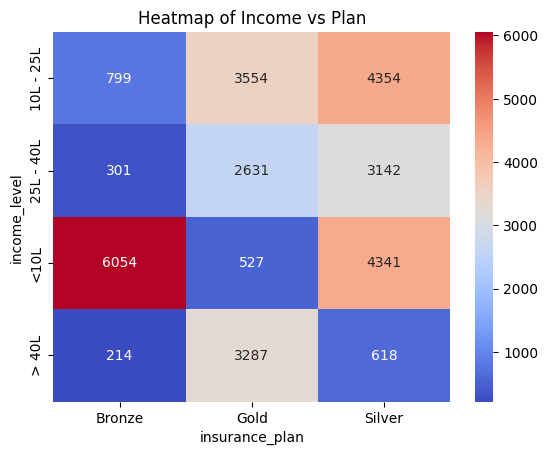

In [44]:
sns.heatmap(crosstab, annot=True, cmap='coolwarm',fmt="d")
plt.title('Heatmap of Income vs Plan')
plt.show()

<h2 align="center">🔧 Feature Engineering</h2>

In [45]:
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0


In [46]:
df.medical_history.unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

### Process medical_history: Assign risk scores and normalize total score

In [47]:
# Define the risk scores for each condition
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

df2[['disease1', 'disease2']] = df2['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())
df2['disease1'] = df2['disease1'].fillna('none')
df2['disease2'] = df2['disease2'].fillna('none')
df2['total_risk_score'] = 0

for disease in ['disease1', 'disease2']:
    df2['total_risk_score'] += df2[disease].map(risk_scores)


# Normalize the risk score to a range of 0 to 1
max_score = df2['total_risk_score'].max()
min_score = df2['total_risk_score'].min()
df2['normalized_risk_score'] = (df2['total_risk_score'] - min_score) / (max_score - min_score)
df2.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,total_risk_score,normalized_risk_score
27099,45,Female,Northwest,Married,2,Overweight,No Smoking,Salaried,10L - 25L,21,Diabetes,Gold,23677,0,diabetes,none,6,0.428571
8256,33,Male,Southwest,Unmarried,0,Obesity,No Smoking,Salaried,25L - 40L,30,High blood pressure,Bronze,12525,0,high blood pressure,none,6,0.428571
5421,29,Male,Northwest,Married,4,Normal,No Smoking,Salaried,25L - 40L,28,Diabetes & High blood pressure,Silver,17679,0,diabetes,high blood pressure,12,0.857143
15312,48,Male,Southeast,Unmarried,0,Overweight,No Smoking,Self-Employed,<10L,1,No Disease,Silver,18175,0,no disease,none,0,0.000000
10653,34,Male,Northwest,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,14,High blood pressure,Silver,15612,0,high blood pressure,none,6,0.428571


### Encode insurance_plan as Ordinal Numeric Values

In [48]:
df2['insurance_plan'].unique()

array(['Bronze', 'Silver', 'Gold'], dtype=object)

In [49]:
df2['insurance_plan'] = df2['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})

### Encode income_level as Ordinal Numeric Values

In [50]:
df2.income_level.unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object)

In [51]:
df2['income_level'] = df2['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})

In [52]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']
df3 = pd.get_dummies(df2, columns=nominal_cols, drop_first=True, dtype=int)
df3.head(3)

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,0,diabetes,none,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,0,diabetes,none,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,0,high blood pressure,none,...,0,0,0,0,0,0,0,0,0,1


In [53]:
df3.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'medical_history', 'insurance_plan', 'annual_premium_amount',
       'genetical_risk', 'disease1', 'disease2', 'total_risk_score',
       'normalized_risk_score', 'gender_Male', 'region_Northwest',
       'region_Southeast', 'region_Southwest', 'marital_status_Unmarried',
       'bmi_category_Obesity', 'bmi_category_Overweight',
       'bmi_category_Underweight', 'smoking_status_Occasional',
       'smoking_status_Regular', 'employment_status_Salaried',
       'employment_status_Self-Employed'],
      dtype='object')

In [54]:
df4 = df3.drop(['medical_history','disease1', 'disease2', 'total_risk_score'], axis=1)
df4.head(3)                

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0,0.428571,0,0,0,0,0,0,0,0,0,0,0,1


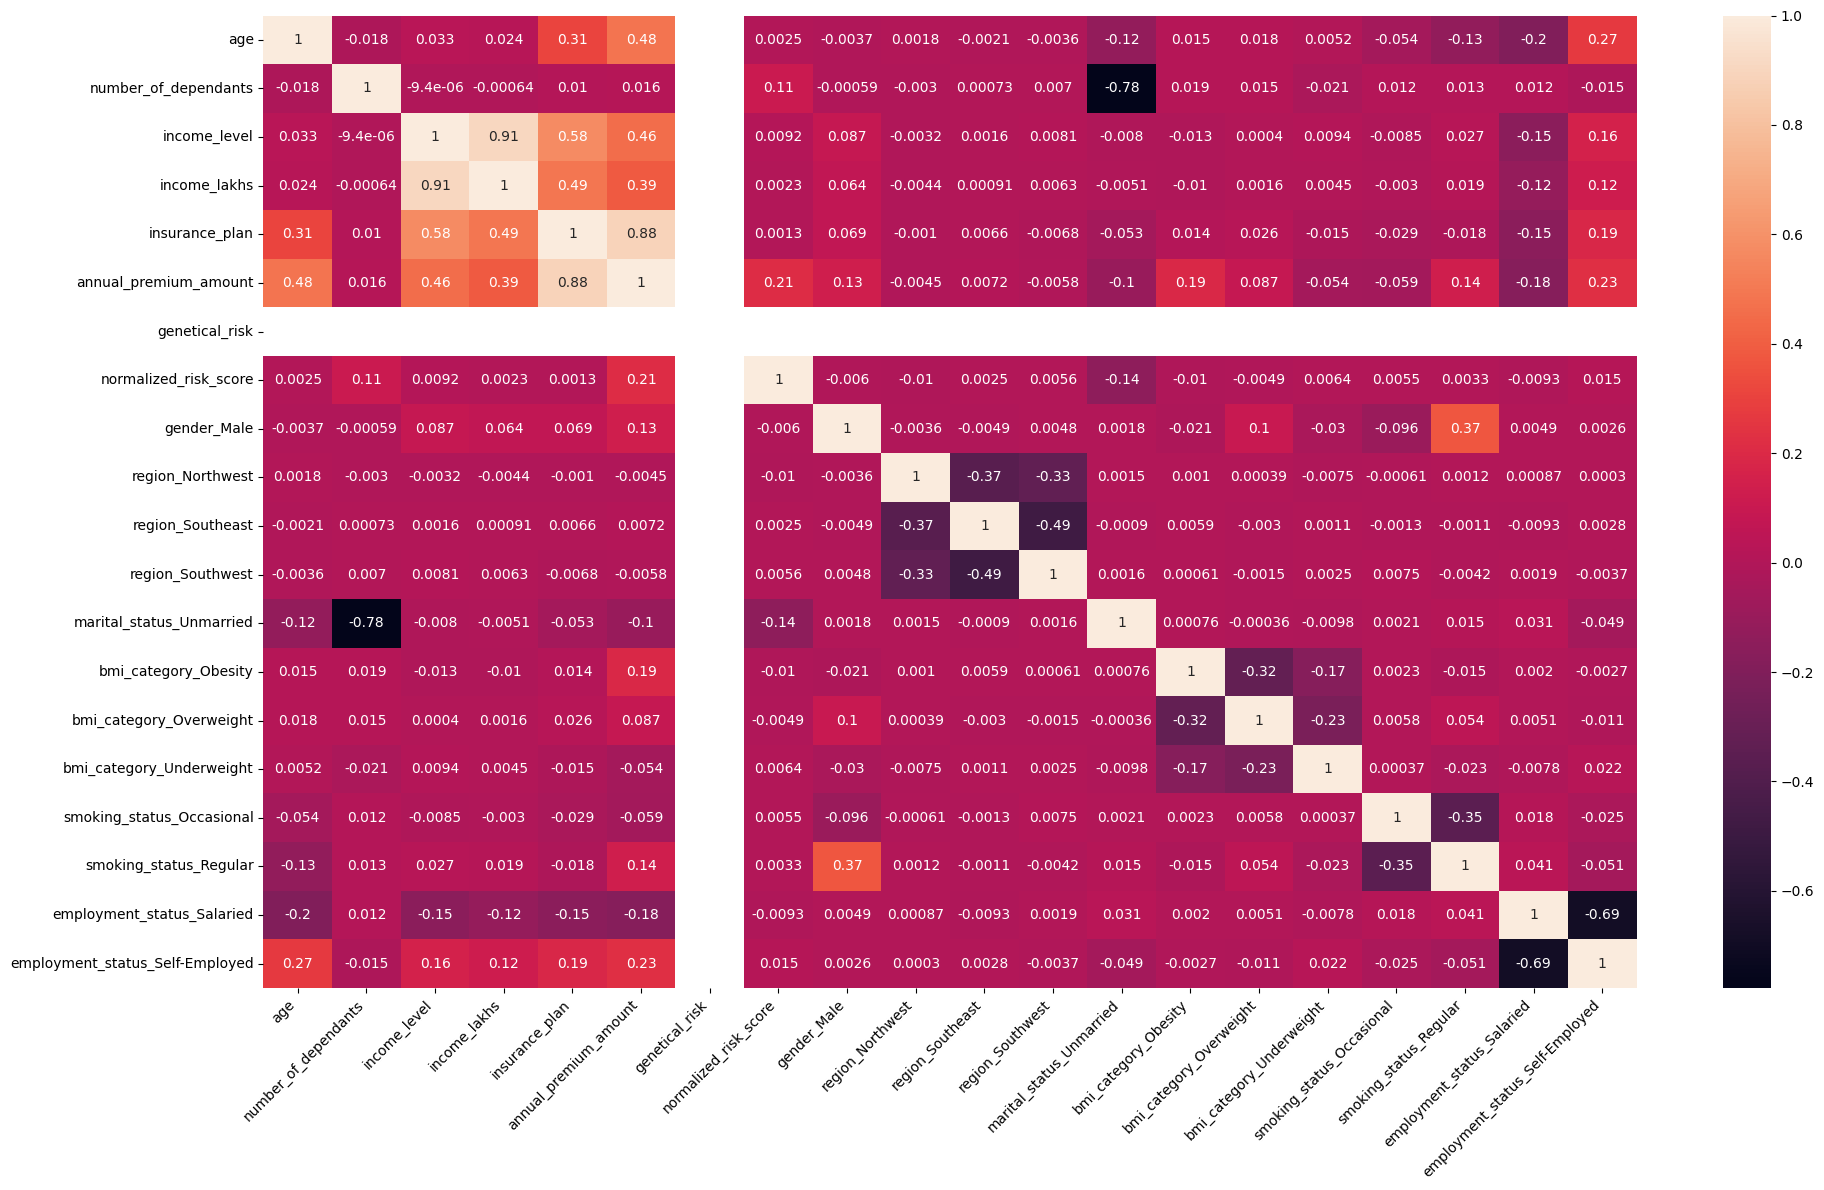

In [55]:
cm = df4.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Calculate VIF for Multicolinearity

In [59]:
X = df4.drop('annual_premium_amount', axis='columns')
y = df4['annual_premium_amount']

from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['age','number_of_dependants', 'income_level',  'income_lakhs', 'insurance_plan', 'genetical_risk']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.0,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000
mean,0.371628,0.477547,0.371225,0.224509,0.544112,0.0,0.426373,0.549125,0.200691,0.352693,0.301992,0.253336,0.196835,0.295051,0.110087,0.173228,0.374656,0.466132,0.354269
std,0.240053,0.284129,0.351111,0.226822,0.379009,0.0,0.240084,0.497589,0.400524,0.477816,0.459129,0.434929,0.397613,0.456073,0.313003,0.378450,0.484042,0.498860,0.478299
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.173913,0.200000,0.000000,0.060606,0.500000,0.0,0.357143,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.347826,0.600000,0.333333,0.161616,0.500000,0.0,0.428571,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.565217,0.600000,0.666667,0.313131,1.000000,0.0,0.428571,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [60]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [61]:
calculate_vif(X) # drop one col which VIF is too high like below drop income_level column

c:\Users\hassa\Downloads\Data\Hassan\Learning\ML Courses\Course-DS Bootcamp-KN\venv312\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Column,VIF
0,age,3.921783
1,number_of_dependants,6.278938
2,income_level,13.890522
3,income_lakhs,11.185596
4,insurance_plan,5.271297
5,genetical_risk,NaN
6,normalized_risk_score,3.810619
7,gender_Male,2.599098
8,region_Northwest,2.123965
9,region_Southeast,2.980842


In [62]:
calculate_vif(X.drop('income_level', axis="columns"))

c:\Users\hassa\Downloads\Data\Hassan\Learning\ML Courses\Course-DS Bootcamp-KN\venv312\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Column,VIF
0,age,3.863055
1,number_of_dependants,6.278147
2,income_lakhs,2.678102
3,insurance_plan,4.574625
4,genetical_risk,NaN
5,normalized_risk_score,3.808345
6,gender_Male,2.591439
7,region_Northwest,2.123277
8,region_Southeast,2.979899
9,region_Southwest,2.708641


In [63]:
# drop income_lakhs due to high VIF value
X_reduced = X.drop('income_level', axis="columns")

<h2 align="center">🚀 Model Training</h2>

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size = 0.30, random_state=10)

# shape of the X_train, X_test, y_train, y_test features
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (20875, 18)
x test:  (8947, 18)
y train:  (20875,)
y test:  (8947,)


In [65]:
lr_model =  LinearRegression()
lr_model.fit(X_train, y_train) 

test_score = lr_model.score(X_test, y_test)
train_score = lr_model.score(X_train, y_train)
train_score, test_score

(0.9534163989489616, 0.9538448451629948)

In [66]:
y_pred = lr_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

score = r2_score(y_test,y_pred)

print("Mean absolute error :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print('------------------------------------')

print("R2 Score: ", score)
print("adjusted R-squared: ", 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))
print('------------------------------------')

print("RMSE / mean:", rmse / df['annual_premium_amount'].mean())
print("RMSE / median:", rmse / df['annual_premium_amount'].median())
print("RMSE / max:", rmse / df['annual_premium_amount'].max())
print('------------------------------------')

Mean absolute error : 2183844.3603124553
MAE : 1128.1022537799042
RMSE : 1477.783597253825
------------------------------------
R2 Score:  0.9538448451629948
adjusted R-squared:  0.9537517904153396
------------------------------------
RMSE / mean: 0.07073339589074824
RMSE / median: 0.07212570634261434
RMSE / max: 0.03399469985171321
------------------------------------


In [67]:
df.annual_premium_amount.describe()

count    29886.000000
mean     20892.303821
std       6936.813440
min       3625.000000
25%      15697.250000
50%      20489.000000
75%      26360.000000
max      43471.000000
Name: annual_premium_amount, dtype: float64

- RMSE: about 14% error on average
- Linear Regression is doing okay, but it cannot capture nonlinearities or interactions

### Quick Rule of Thumb
- RMSE <10% : excellent
- RMSE 10–30% : moderate
- RMSE >30% : poor

In [68]:
X_test.shape

(8947, 18)

In [69]:
lr_model.intercept_

np.float64(5935.981289344605)

In [70]:
lr_model.coef_

array([ 7.01623933e+03, -1.31176470e+03, -7.08193369e+02,  1.48359882e+04,
       -4.54747351e-12,  6.05362412e+03,  3.75582688e+01, -5.52508721e+01,
       -1.96225429e+01, -2.22896756e+01, -7.00320200e+02,  3.92681271e+03,
        1.97945605e+03,  6.12866236e+02,  8.37395101e+02,  2.80066184e+03,
       -4.54913671e+01,  2.43078421e+02])

### Checking Feature Importance Manually


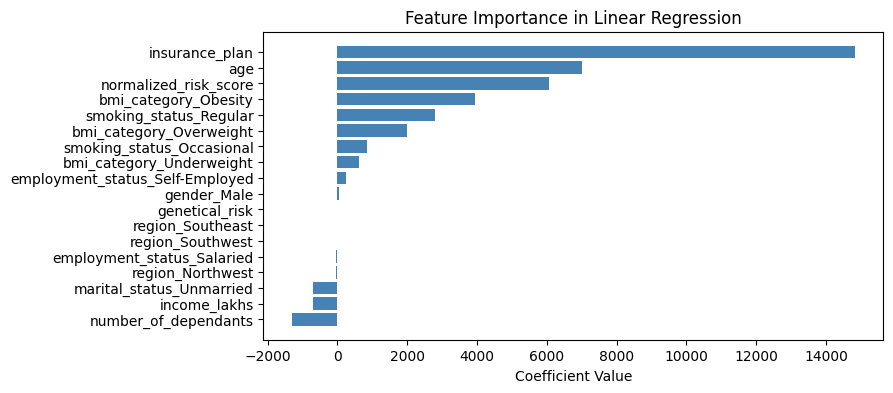

In [71]:
feature_importance = lr_model.coef_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

In [72]:
coef_df['Coefficients'].sort_values(ascending=False)

insurance_plan                     1.483599e+04
age                                7.016239e+03
normalized_risk_score              6.053624e+03
bmi_category_Obesity               3.926813e+03
smoking_status_Regular             2.800662e+03
bmi_category_Overweight            1.979456e+03
smoking_status_Occasional          8.373951e+02
bmi_category_Underweight           6.128662e+02
employment_status_Self-Employed    2.430784e+02
gender_Male                        3.755827e+01
genetical_risk                    -4.547474e-12
region_Southeast                  -1.962254e+01
region_Southwest                  -2.228968e+01
employment_status_Salaried        -4.549137e+01
region_Northwest                  -5.525087e+01
marital_status_Unmarried          -7.003202e+02
income_lakhs                      -7.081934e+02
number_of_dependants              -1.311765e+03
Name: Coefficients, dtype: float64

### Ridge/Lasso/ElasticNet Regression Model

In [73]:
model_rg = Ridge(alpha=1)

model_rg.fit(X_train, y_train)

y_pred_rg = model_rg.predict(X_test)

mse = mean_squared_error(y_test, y_pred_rg)
mae = mean_absolute_error(y_test, y_pred_rg)
rmse = np.sqrt(mse)

score = r2_score(y_test,y_pred_rg)

print("Mean absolute error :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print('------------------------------------')

print("R2 Score: ", score)
print("adjusted R-squared: ", 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))
print('------------------------------------')

print("RMSE / mean:", rmse / df['annual_premium_amount'].mean())
print("RMSE / median:", rmse / df['annual_premium_amount'].median())
print("RMSE / max:", rmse / df['annual_premium_amount'].max())
print('------------------------------------')

Mean absolute error : 2183803.9339715634
MAE : 1127.9696817187025
RMSE : 1477.769919159124
------------------------------------
R2 Score:  0.9538456995663842
adjusted R-squared:  0.9537526465413164
------------------------------------
RMSE / mean: 0.07073274119537247
RMSE / median: 0.07212503876026766
RMSE / max: 0.033994385202988746
------------------------------------


In [74]:
lasso=Lasso()

lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

mse = mean_squared_error(y_test, y_pred_lasso)
mae = mean_absolute_error(y_test, y_pred_lasso)
rmse = np.sqrt(mse)

score = r2_score(y_test,y_pred_lasso)

print("Mean absolute error :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print('------------------------------------')

print("R2 Score: ", score)
print("adjusted R-squared: ", 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))
print('------------------------------------')

print("RMSE / mean:", rmse / df['annual_premium_amount'].mean())
print("RMSE / median:", rmse / df['annual_premium_amount'].median())
print("RMSE / max:", rmse / df['annual_premium_amount'].max())
print('------------------------------------')

Mean absolute error : 2184024.1961180475
MAE : 1127.6540348612086
RMSE : 1477.8444424627537
------------------------------------
R2 Score:  0.9538410443658304
adjusted R-squared:  0.9537479819552777
------------------------------------
RMSE / mean: 0.07073630821719387
RMSE / median: 0.07212867599505851
RMSE / max: 0.033996099525264056
------------------------------------


In [75]:
from sklearn.linear_model import LassoCV

lassocv = LassoCV(
    alphas=100,      # automatically generate
    cv=5,
    max_iter=10000
)

lassocv.fit(X_train, y_train)
y_pred_lassocv = lassocv.predict(X_test)


mse = mean_squared_error(y_test, y_pred_lassocv)
mae = mean_absolute_error(y_test, y_pred_lassocv)
rmse = np.sqrt(mse)

score = r2_score(y_test, y_pred_lassocv)

print("Best alpha:", lassocv.alpha_)
print('------------------------------------')

print("Mean absolute error :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print('------------------------------------')

print("R2 Score: ", score)
print("adjusted R-squared: ", 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))
print('------------------------------------')

print("RMSE / mean:", rmse / df['annual_premium_amount'].mean())
print("RMSE / median:", rmse / df['annual_premium_amount'].median())
print("RMSE / max:", rmse / df['annual_premium_amount'].max())
print('------------------------------------')

Best alpha: 2.3245798695112776
------------------------------------
Mean absolute error : 2185253.5195373856
MAE : 1127.3000402546431
RMSE : 1478.2603016848507
------------------------------------
R2 Score:  0.9538150628381192
adjusted R-squared:  0.9537219480454542
------------------------------------
RMSE / mean: 0.07075621311737416
RMSE / median: 0.0721489727016863
RMSE / max: 0.03400566588495435
------------------------------------


In [76]:
elastic_cv = ElasticNetCV(
    l1_ratio=[0.1,0.3,0.5,0.7,0.9,1],
    alphas=100,
    cv=5,
    random_state=42
)

elastic_cv.fit(X_train, y_train)
y_pred_elastic = elastic_cv.predict(X_test)

r2_score(y_test,y_pred_elastic)

mse = mean_squared_error(y_test, y_pred_elastic)
mae = mean_absolute_error(y_test, y_pred_elastic)
rmse = np.sqrt(mse)

score = r2_score(y_test,y_pred_elastic)

print("Best alpha:", elastic_cv.alpha_)
print("Best l1_ratio:", elastic_cv.l1_ratio_)
print('------------------------------------')

print("Mean absolute error :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print('------------------------------------')

print("R2 Score: ", score)
print("adjusted R-squared: ", 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))
print('------------------------------------')

print("RMSE / mean:", rmse / df['annual_premium_amount'].mean())
print("RMSE / median:", rmse / df['annual_premium_amount'].median())
print("RMSE / max:", rmse / df['annual_premium_amount'].max())
print('------------------------------------')

Best alpha: 2.3245798695112776
Best l1_ratio: 1.0
------------------------------------
Mean absolute error : 2185253.5195373856
MAE : 1127.3000402546431
RMSE : 1478.2603016848507
------------------------------------
R2 Score:  0.9538150628381192
adjusted R-squared:  0.9537219480454542
------------------------------------
RMSE / mean: 0.07075621311737416
RMSE / median: 0.0721489727016863
RMSE / max: 0.03400566588495435
------------------------------------


### XGBRegressor

In [77]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor()
# model_xgb = XGBRegressor(n_estimators=20, max_depth=3)
model_xgb.fit(X_train, y_train)
model_xgb.score(X_test, y_test)

0.9979538321495056

In [78]:
y_pred_xg = model_xgb.predict(X_test)

mse = mean_squared_error(y_test, y_pred_xg)
mae = mean_absolute_error(y_test, y_pred_xg)
rmse = np.sqrt(mse)

score = r2_score(y_test,y_pred_xg)

print("Mean absolute error :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print('------------------------------------')

print("R2 Score: ", score)
print("adjusted R-squared: ", 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))
print('------------------------------------')

print("RMSE / mean:", rmse / df['annual_premium_amount'].mean())
print("RMSE / median:", rmse / df['annual_premium_amount'].median())
print("RMSE / max:", rmse / df['annual_premium_amount'].max())
print('------------------------------------')

Mean absolute error : 96814.2109375
MAE : 262.8409423828125
RMSE : 311.14982072548264
------------------------------------
R2 Score:  0.9979538321495056
adjusted R-squared:  0.9979497068110974
------------------------------------
RMSE / mean: 0.01489303541574679
RMSE / median: 0.015186188722020726
RMSE / max: 0.007157641202766963
------------------------------------


In [79]:
model_xgb = XGBRegressor()

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3]
}

random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
random_search.best_score_

np.float64(0.998059352238973)

In [80]:
random_search.best_params_

{'subsample': 1.0,
 'n_estimators': 200,
 'min_child_weight': 5,
 'max_depth': 4,
 'learning_rate': 0.1,
 'gamma': 0,
 'colsample_bytree': 0.8}

In [81]:
from sklearn.model_selection import GridSearchCV

model_xgb = XGBRegressor()

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.3]
}

grid_search = GridSearchCV(
    estimator=model_xgb,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)
grid_search.best_score_

Fitting 5 folds for each of 96 candidates, totalling 480 fits


np.float64(0.9981253266334533)

In [82]:
grid_search.best_params_

{'colsample_bytree': 1.0,
 'gamma': 0,
 'learning_rate': 0.05,
 'max_depth': 5,
 'n_estimators': 200,
 'subsample': 1.0}

In [83]:
best_model = grid_search.best_estimator_

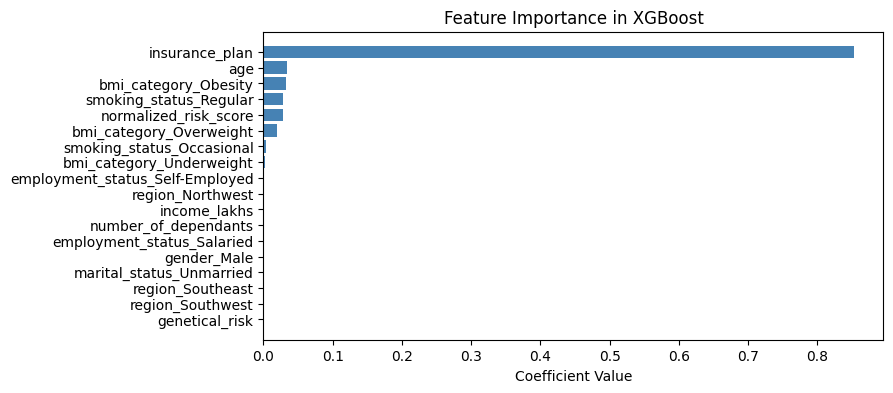

In [84]:
feature_importance = best_model.feature_importances_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in XGBoost')
plt.show()

### XGBoost provides feature importance scores, but it does not give detailed explanations of how each feature influences predictions.

## Error Analysis

In [85]:
X_test.shape

(8947, 18)

In [86]:
y_pred = best_model.predict(X_test)

residuals = y_pred-y_test
residuals_per = residuals*100/y_test

results_df = pd.DataFrame({
    'actual': y_test, 
    'predicted': y_pred, 
    'diff': residuals, 
    'diff_pct': residuals_per
})
results_df.head(15)


,actual,predicted,diff,diff_pct
19713,26895,26568.919922,-326.080078,-1.212419
14750,22734,22991.042969,257.042969,1.130654
19932,21198,21525.939453,327.939453,1.547030
29643,9100,9113.763672,13.763672,0.151249
17076,26434,26567.421875,133.421875,0.504736
20314,21839,21473.197266,-365.802734,-1.674998
24893,28185,28551.937500,366.937500,1.301889
26722,31610,31550.099609,-59.900391,-0.189498
25844,26434,26567.421875,133.421875,0.504736
10731,13121,13636.053711,515.053711,3.925415


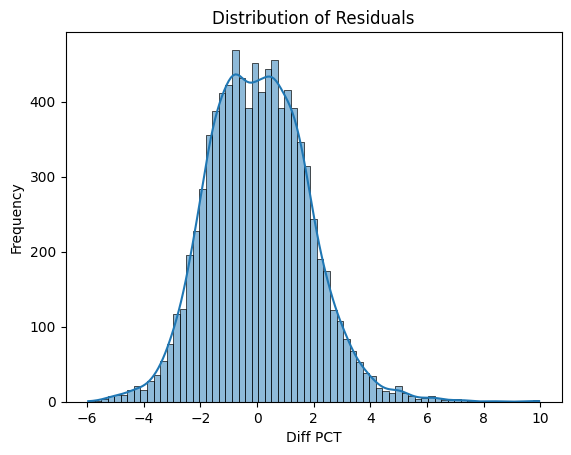

In [87]:
sns.histplot(results_df['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

Most of the prediction errors fall between **-6 and +10**

In [88]:
X_test.shape

(8947, 18)

In [89]:
results_df.shape

(8947, 4)

In [90]:
extreme_error_threshold = 10  # You can adjust this threshold based on your domain knowledge or requirements
extreme_results_df = results_df[np.abs(results_df['diff_pct']) > extreme_error_threshold]
extreme_results_df.head()

,actual,predicted,diff,diff_pct


In [91]:
extreme_results_df.shape

(0, 4)

In [92]:
extreme_errors_pct = extreme_results_df.shape[0]*100/X_test.shape[0]
extreme_errors_pct

0.0

Now, we have zero error left at 10% threshold after removing age< 25 data

In [93]:
extreme_results_df[abs(extreme_results_df.diff_pct)>50].sort_values("diff_pct",ascending=False)

,actual,predicted,diff,diff_pct


In [94]:
extreme_results_df[abs(extreme_results_df.diff_pct)>50].sort_values("diff_pct",ascending=False)

,actual,predicted,diff,diff_pct


Now, we have zero error left at 50% threshold after removing age< 25 data

### Export the Model

In [96]:
from joblib import dump

dump(best_model, "artifacts/model_rest.joblib")
scaler_with_cols = {
    'scaler': scaler,
    'cols_to_scale': cols_to_scale
}
dump(scaler_with_cols, "artifacts/scaler_rest.joblib")

['artifacts/scaler_rest.joblib']